# Undersampling plus class correction experiments

Protein homology dataset from imblearn.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from imblearn.datasets import fetch_datasets
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline

from sklearn.ensemble import GradientBoostingClassifier
from sklearn.calibration import CalibrationDisplay
from sklearn.model_selection import LearningCurveDisplay, train_test_split 

## Load diabetes dataset

In [2]:
# Load dataset from imbalanced-learn
def load_dataset(dataset):
    
    data = fetch_datasets()[dataset]
    data.target = np.where(data.target < 0, 0, 1)
    X, y = data.data, data.target
    return X, y

X, y = load_dataset("protein_homo")
print(f"Data size: {X.shape}")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.4, random_state=0)

print(f"Train set size: {X_train.shape}")
print(f"Test set size: {X_test.shape}")

Data size: (145751, 74)
Train set size: (87450, 74)
Test set size: (58301, 74)


## Target: Protein homology

In [3]:
# target
minority = y_train.sum()
majority = (len(y_train) - minority)

prevalence = np.round(y_train.mean(), 4)
ir = np.round(majority/minority, 2)

print(f"prevalence: {prevalence}")
print(f"IR: {ir}")

prevalence: 0.0086
IR: 114.67


## Learning curve original distributions

The dataset is quite big so we'll examine the learning curve to determine the minimum size required for a reliable model.

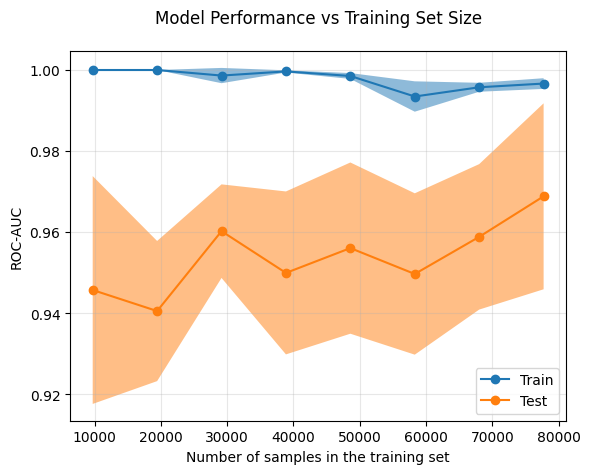

In [4]:
model = GradientBoostingClassifier(random_state=0)

train_sizes = [.1, .2, .3, .4, .5, .6, .7, .8]

LearningCurveDisplay.from_estimator(
    model,
    X, y, 
    train_sizes=train_sizes, 
    cv=3,
    scoring='roc_auc',
    shuffle=True,     # <--- shuffles the training folds before slicing
    random_state=0,   # <--- Guarantees reproducibility of the shuffles
    line_kw = {"marker": "o"},
)

plt.title('Model Performance vs Training Set Size', pad=20)
plt.ylabel('ROC-AUC')
plt.grid(alpha=0.3)
# plt.savefig("../../mlid-book/resources/ch5/ch5-fig1.png", dpi=300, bbox_inches="tight")
plt.show()

My take is that classes are so well separated here, that increasing the dataset isn't that important, that's why see see a similar performance across training data sizes.

## Learning curve undersampling

With big datasets, undersampling may help improve training speed. To this end, keeping all of the positive examples, which are usually precious, we'll examine how much of the majority class we need to obtain reliable models.

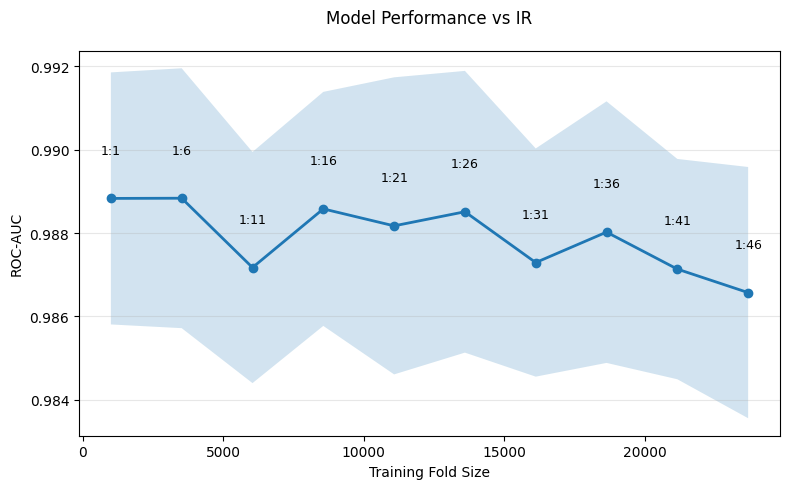

In [5]:
from sklearn.model_selection import cross_val_score, StratifiedKFold

roc_auc_scores, roc_auc_stds, dataset_sizes = [], [], []

# the IR is 114 for this dataset. We'll examine up to 
# an IR of 50 in steps of 5.
for ratio in range(1, 50, 5):
    
    # define number of minority and majority in training set
    # 2 of the 3 cv fold
    minority = int(np.sum(y_train)/3*2)
    majority = minority * ratio
    us_dict = {1:minority, 0:majority}

    # pipeline, so cross-validate tests in original data distribution
    model = Pipeline([
        ('us', RandomUnderSampler(sampling_strategy=us_dict, random_state=0)),
        ('cls', GradientBoostingClassifier(random_state=0))
    ])
    
    cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=0)
    scores = cross_val_score(model, X_train, y_train, cv=cv, scoring='roc_auc')
    roc_auc_scores.append(scores.mean())
    roc_auc_stds.append(scores.std())

    # Calculate total dataset size after undersampling
    dataset_size = minority + majority
    dataset_sizes.append(dataset_size)

# Plot results
plt.figure(figsize=(8, 5))
plt.plot(dataset_sizes, roc_auc_scores, marker='o', linewidth=2, markersize=6)
plt.fill_between(dataset_sizes, 
                 [score - std for score, std in zip(roc_auc_scores, roc_auc_stds)],
                 [score + std for score, std in zip(roc_auc_scores, roc_auc_stds)],
                 alpha=0.2)

# Annotate IR on top of dots
for size, score, ratio in zip(dataset_sizes, roc_auc_scores, range(1, 50, 5)):
    plt.text(size, score + 0.001, f'1:{ratio}', ha='center', va='bottom', fontsize=9)

plt.title('Model Performance vs IR', pad=20)
plt.ylabel('ROC-AUC')
plt.xlabel('Training Fold Size')
plt.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

The performance plot seems quite stable on the ratio of minority to majority, so I'll test 1, 10 and 20.

## Test model performance and training speed

We want to understand if reducing data size helps us train models faster.

In [6]:
import time
from sklearn.metrics import roc_auc_score, log_loss

### Without resampling

In [7]:
results = {
    'training_set_size': [],
    'roc_auc_mean': [],
    'roc_auc_std': [],
    'logloss_mean': [],
    'logloss_std': [],
    'training_time_mean': [],
    'training_time_std': []
}

for train_size in ['full', 'half']:
    
    if train_size == 'full':
        X_train_subset = X_train
        y_train_subset = y_train
    else:
        X_train_subset = X_train[:len(X_train)//2]
        y_train_subset = y_train[:len(y_train)//2]
    
    roc_scores = []
    logloss_scores = []
    train_times = []
    
    cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=0)
    
    for train_idx, test_idx in cv.split(X_train_subset, y_train_subset):
        X_cv_train = X_train_subset[train_idx]
        X_cv_test = X_train_subset[test_idx]
        y_cv_train = y_train_subset[train_idx]
        y_cv_test = y_train_subset[test_idx]
        
        model = GradientBoostingClassifier(random_state=0)
        
        start_time = time.time()
        model.fit(X_cv_train, y_cv_train)
        train_time = time.time() - start_time
        train_times.append(train_time)
        
        y_pred_proba = model.predict_proba(X_cv_test)[:, 1]
        roc_auc = roc_auc_score(y_cv_test, y_pred_proba)
        roc_scores.append(roc_auc)
        ll = log_loss(y_cv_test, y_pred_proba)
        logloss_scores.append(ll)
    
    results['training_set_size'].append(train_size)
    results['roc_auc_mean'].append(np.mean(roc_scores))
    results['roc_auc_std'].append(np.std(roc_scores))
    results['logloss_mean'].append(np.mean(logloss_scores))
    results['logloss_std'].append(np.std(logloss_scores))
    results['training_time_mean'].append(np.mean(train_times))
    results['training_time_std'].append(np.std(train_times))

df_ = pd.DataFrame(results)
df_

,training_set_size,roc_auc_mean,roc_auc_std,logloss_mean,logloss_std,training_time_mean,training_time_std
0,full,0.987652,0.002329,0.018585,0.001088,56.229988,0.282171
1,half,0.981668,0.002577,0.026653,0.006228,27.582589,0.197583


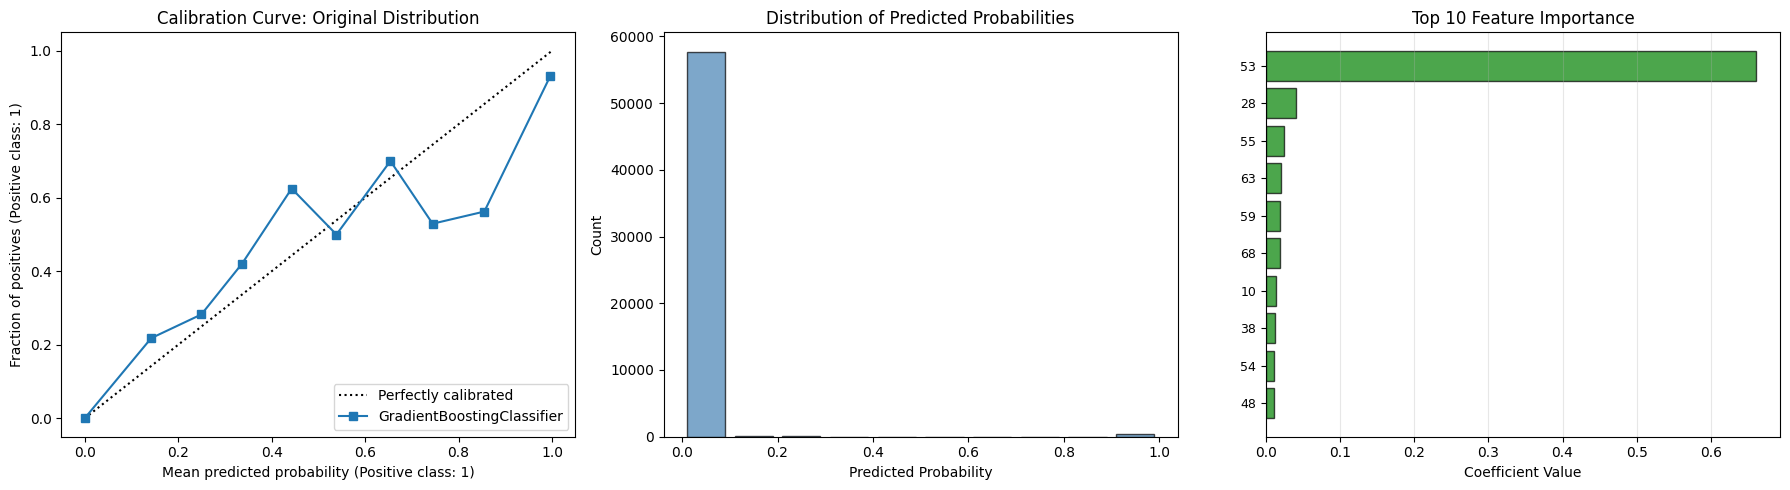

In [8]:
# Plot calibration curve, bar plot with number of samples 
# per bin of probability distribution, and feature importance

model = GradientBoostingClassifier(random_state=0)
model.fit(X_train, y_train)
probs = model.predict_proba(X_test)[:, 1]

# Create figure with 3 subplots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Calibration curve
CalibrationDisplay.from_estimator(model, X_test, y_test, n_bins=10, ax=axes[0])
axes[0].set_title('Calibration Curve: Original Distribution')

# Plot 2: Bar plot of predicted probabilities
bins = np.linspace(0, 1, 11)
counts, _ = np.histogram(probs, bins=bins)
bin_centers = (bins[:-1] + bins[1:]) / 2
bin_width = 0.08

axes[1].bar(bin_centers, counts, width=bin_width, edgecolor='black', alpha=0.7, color='steelblue')
axes[1].set_xlabel('Predicted Probability')
axes[1].set_ylabel('Count')
axes[1].set_title('Distribution of Predicted Probabilities')

# Plot 3: Feature importance (top 10 features)
feature_importance = pd.DataFrame({
    'feature': list(range(1, X.shape[1] + 1)),
    'importance': model.feature_importances_
}).sort_values('importance', key=abs, ascending=False).head(10)

feature_importance_sorted = feature_importance.sort_values('importance')

axes[2].barh(range(len(feature_importance_sorted)), feature_importance_sorted['importance'], 
            color=['green' if x > 0 else 'red' for x in feature_importance_sorted['importance']],
            edgecolor='black', alpha=0.7)
axes[2].set_yticks(range(len(feature_importance_sorted)))
axes[2].set_yticklabels(feature_importance_sorted['feature'], fontsize=9)
axes[2].set_xlabel('Coefficient Value')
axes[2].set_title('Top 10 Feature Importance')
axes[2].grid(axis='x', alpha=0.3)

plt.tight_layout()
outputdir="../../mlid-book/resources/ch5/ch5-4.png"
plt.savefig(outputdir, dpi=150, bbox_inches="tight", facecolor="white")
plt.show()

### With resampling

In [9]:
# the number of samples in 2 fold of cross-validation
minority = int(np.sum(y_train) / 3 * 2)

for ratio in [1, 10, 20]:
    majority = minority * ratio
    us_dict = {1: minority, 0: majority}
    
    roc_scores = []
    train_times = []
    logloss_scores = []
    
    cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=0)
    
    for train_idx, test_idx in cv.split(X_train, y_train):
        X_cv_train = X_train[train_idx] 
        X_cv_test = X_train[test_idx]
        y_cv_train = y_train[train_idx]
        y_cv_test = y_train[test_idx]
        
        us = RandomUnderSampler(sampling_strategy=us_dict, random_state=0)
        X_us, y_us = us.fit_resample(X_cv_train, y_cv_train)
        
        model = GradientBoostingClassifier(random_state=0)
        
        start_time = time.time()
        model.fit(X_us, y_us)
        train_time = time.time() - start_time
        train_times.append(train_time)
        
        y_pred_proba = model.predict_proba(X_cv_test)[:, 1]
        roc_auc = roc_auc_score(y_cv_test, y_pred_proba)
        roc_scores.append(roc_auc)
        ll = log_loss(y_cv_test, y_pred_proba)
        logloss_scores.append(ll)
    
    results['training_set_size'].append(f'1:{ratio}')
    results['roc_auc_mean'].append(np.mean(roc_scores))
    results['roc_auc_std'].append(np.std(roc_scores))
    results['logloss_mean'].append(np.mean(logloss_scores))
    results['logloss_std'].append(np.std(logloss_scores))
    results['training_time_mean'].append(np.mean(train_times))
    results['training_time_std'].append(np.std(train_times))

df_ = pd.DataFrame(results)
df_

,training_set_size,roc_auc_mean,roc_auc_std,logloss_mean,logloss_std,training_time_mean,training_time_std
0,full,0.987652,0.002329,0.018585,0.001088,56.229988,0.282171
1,half,0.981668,0.002577,0.026653,0.006228,27.582589,0.197583
2,1:1,0.988831,0.003023,0.104828,0.008605,0.948427,0.000416
3,1:10,0.987709,0.003673,0.021894,0.002587,5.269760,0.002271
4,1:20,0.988376,0.004198,0.015785,0.000731,10.049096,0.003946


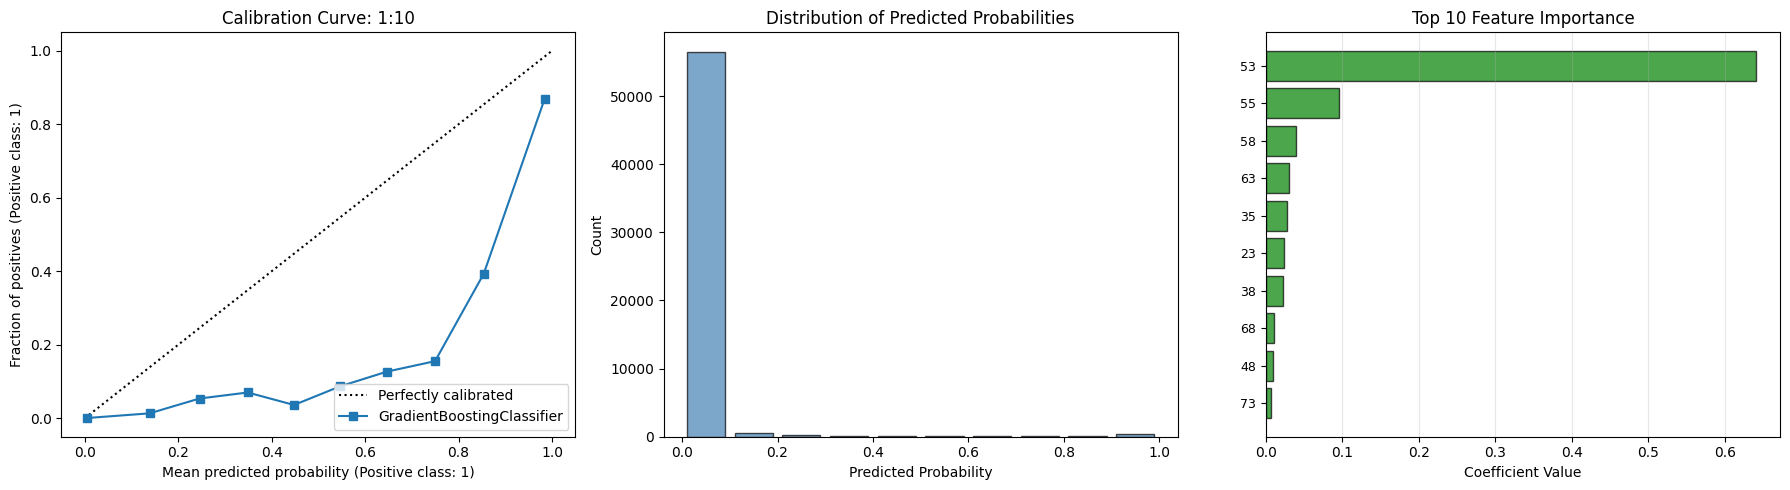

In [10]:
us_dict = {1: minority, 0: minority * 10}

us = RandomUnderSampler(sampling_strategy=us_dict, random_state=0)
X_us, y_us = us.fit_resample(X_cv_train, y_cv_train)

model = GradientBoostingClassifier(random_state=0)
model.fit(X_us, y_us)
probs = model.predict_proba(X_test)[:, 1]

# Create figure with 3 subplots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Calibration curve
CalibrationDisplay.from_estimator(model, X_test, y_test, n_bins=10, ax=axes[0])
axes[0].set_title('Calibration Curve: 1:10')

# Plot 2: Bar plot of predicted probabilities
bins = np.linspace(0, 1, 11)
counts, _ = np.histogram(probs, bins=bins)
bin_centers = (bins[:-1] + bins[1:]) / 2
bin_width = 0.08

axes[1].bar(bin_centers, counts, width=bin_width, edgecolor='black', alpha=0.7, color='steelblue')
axes[1].set_xlabel('Predicted Probability')
axes[1].set_ylabel('Count')
axes[1].set_title('Distribution of Predicted Probabilities')

# Plot 3: Feature importance (top 10 features)
feature_importance = pd.DataFrame({
    'feature': list(range(1, X.shape[1] + 1)),
    'importance': model.feature_importances_
}).sort_values('importance', key=abs, ascending=False).head(10)

feature_importance_sorted = feature_importance.sort_values('importance')

axes[2].barh(range(len(feature_importance_sorted)), feature_importance_sorted['importance'], 
            color=['green' if x > 0 else 'red' for x in feature_importance_sorted['importance']],
            edgecolor='black', alpha=0.7)
axes[2].set_yticks(range(len(feature_importance_sorted)))
axes[2].set_yticklabels(feature_importance_sorted['feature'], fontsize=9)
axes[2].set_xlabel('Coefficient Value')
axes[2].set_title('Top 10 Feature Importance')
axes[2].grid(axis='x', alpha=0.3)

plt.tight_layout()
outputdir="../../mlid-book/resources/ch5/ch5-5.png"
plt.savefig(outputdir, dpi=150, bbox_inches="tight", facecolor="white")
plt.show()

### Restoring class prevalence

In [11]:
def define_weights(current_dist):

    class_weight_for_prevalence_correction = {
        0: (1 - prevalence) / (1 - current_dist),
        1: prevalence / current_dist,
    }

    return class_weight_for_prevalence_correction

In [12]:
# the number of samples in 2 fold of cross-validation
minority = int(np.sum(y_train) / 3 * 2)

for ratio in [1, 10, 20]:
    majority = minority * ratio
    us_dict = {1: minority, 0: majority}
    
    roc_scores = []
    train_times = []
    logloss_scores = []
    
    cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=0)
    
    for train_idx, test_idx in cv.split(X_train, y_train):
        X_cv_train = X_train[train_idx] 
        X_cv_test = X_train[test_idx]
        y_cv_train = y_train[train_idx]
        y_cv_test = y_train[test_idx]
        
        us = RandomUnderSampler(sampling_strategy=us_dict, random_state=0)
        X_us, y_us = us.fit_resample(X_cv_train, y_cv_train)

        cw = define_weights(np.mean(y_us))
        sample_w = np.where(y_us == 0, cw[0], cw[1])
        
        model = GradientBoostingClassifier(random_state=0)
        
        start_time = time.time()
        model.fit(X_us, y_us, sample_weight=sample_w)
        train_time = time.time() - start_time
        train_times.append(train_time)
        
        y_pred_proba = model.predict_proba(X_cv_test)[:, 1]
        roc_auc = roc_auc_score(y_cv_test, y_pred_proba)
        roc_scores.append(roc_auc)
        ll = log_loss(y_cv_test, y_pred_proba)
        logloss_scores.append(ll)
    
    results['training_set_size'].append(f'1:{ratio} - restored')
    results['roc_auc_mean'].append(np.mean(roc_scores))
    results['roc_auc_std'].append(np.std(roc_scores))
    results['logloss_mean'].append(np.mean(logloss_scores))
    results['logloss_std'].append(np.std(logloss_scores))
    results['training_time_mean'].append(np.mean(train_times))
    results['training_time_std'].append(np.std(train_times))

df_ = pd.DataFrame(results)
df_

,training_set_size,roc_auc_mean,roc_auc_std,logloss_mean,logloss_std,training_time_mean,training_time_std
0,full,0.987652,0.002329,0.018585,0.001088,56.229988,0.282171
1,half,0.981668,0.002577,0.026653,0.006228,27.582589,0.197583
2,1:1,0.988831,0.003023,0.104828,0.008605,0.948427,0.000416
3,1:10,0.987709,0.003673,0.021894,0.002587,5.269760,0.002271
4,1:20,0.988376,0.004198,0.015785,0.000731,10.049096,0.003946
5,1:1 - restored,0.923891,0.012645,1.604122,0.370774,0.952601,0.004747
6,1:10 - restored,0.978626,0.004547,0.175714,0.013285,5.271903,0.002435
7,1:20 - restored,0.981559,0.003933,0.086755,0.014665,10.046667,0.002014


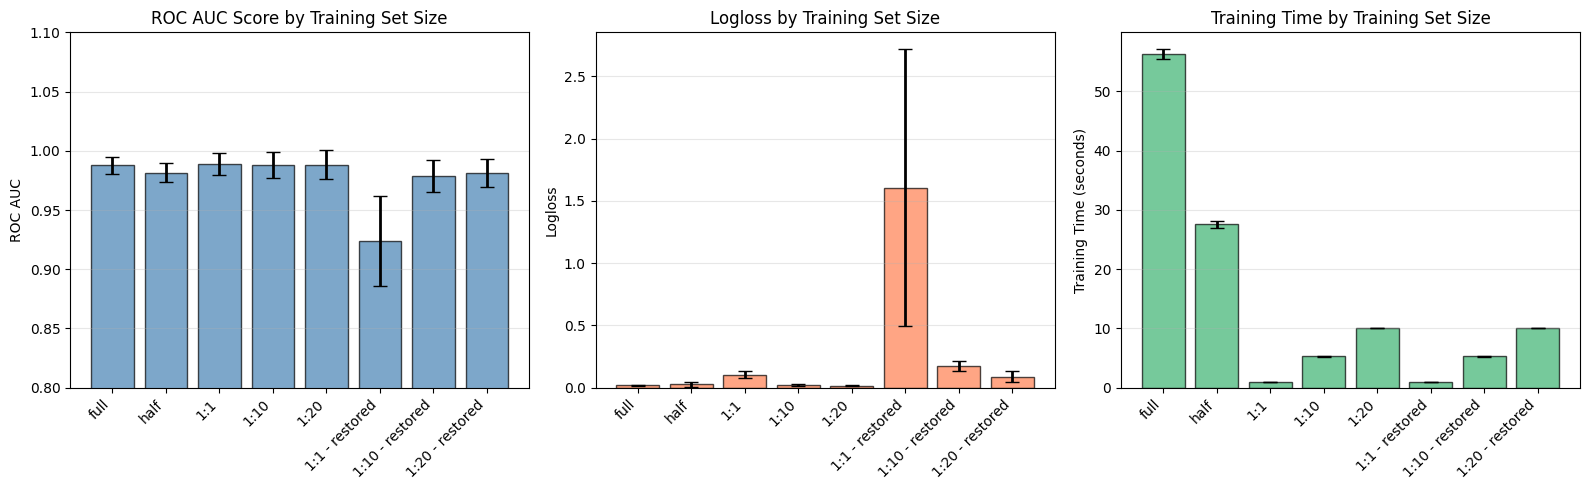

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Plot 1: ROC AUC
axes[0].bar(range(len(df_)), df_['roc_auc_mean'], 
           yerr=3*df_['roc_auc_std'], capsize=5, 
           color='steelblue', edgecolor='black', alpha=0.7, error_kw={'elinewidth': 2})
axes[0].set_xticks(range(len(df_)))
axes[0].set_xticklabels(df_['training_set_size'], rotation=45, ha='right')
axes[0].set_ylabel('ROC AUC')
axes[0].set_ylim(0.8, 1.1)  # Set y-axis limits
axes[0].set_title('ROC AUC Score by Training Set Size')
axes[0].grid(axis='y', alpha=0.3)

# Plot 2: Logloss
axes[1].bar(range(len(df_)), df_['logloss_mean'], 
           yerr=3*df_['logloss_std'], capsize=5, 
           color='coral', edgecolor='black', alpha=0.7, error_kw={'elinewidth': 2})
axes[1].set_xticks(range(len(df_)))
axes[1].set_xticklabels(df_['training_set_size'], rotation=45, ha='right')
axes[1].set_ylabel('Logloss')
axes[1].set_title('Logloss by Training Set Size')
axes[1].grid(axis='y', alpha=0.3)

# Plot 3: Training Time
axes[2].bar(range(len(df_)), df_['training_time_mean'], 
           yerr=3*df_['training_time_std'], capsize=5, 
           color='mediumseagreen', edgecolor='black', alpha=0.7, error_kw={'elinewidth': 2})
axes[2].set_xticks(range(len(df_)))
axes[2].set_xticklabels(df_['training_set_size'], rotation=45, ha='right')
axes[2].set_ylabel('Training Time (seconds)')
axes[2].set_title('Training Time by Training Set Size')
axes[2].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

Undersampling does not reduce model performance in terms of ROC-AUC. The log-loss increases as the ratio between the minority and majority class decreases, as expected. Restoring class prevalence after undersampling does affect model performance in the 1:1 case, not so much with bigger fractions of the majority. The logloss does not improve after restoration, on the contrary, so for this model, undersampling doesn't really help.

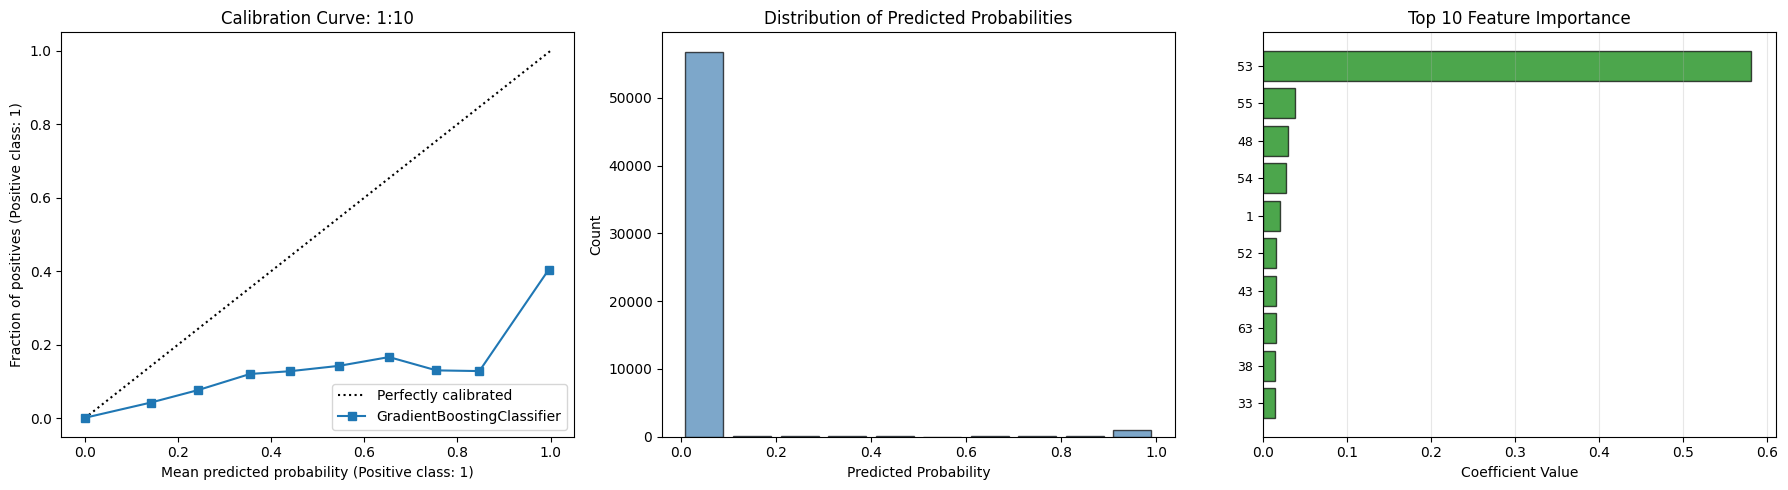

In [14]:
us_dict = {1: minority, 0: minority * 10}

us = RandomUnderSampler(sampling_strategy=us_dict, random_state=0)
X_us, y_us = us.fit_resample(X_cv_train, y_cv_train)

cw = define_weights(np.mean(y_us))
sample_w = np.where(y_us == 0, cw[0], cw[1])

model = GradientBoostingClassifier(random_state=0)
model.fit(X_us, y_us, sample_weight=sample_w)
probs = model.predict_proba(X_test)[:, 1]

# Create figure with 3 subplots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Calibration curve
CalibrationDisplay.from_estimator(model, X_test, y_test, n_bins=10, ax=axes[0])
axes[0].set_title('Calibration Curve: 1:10')

# Plot 2: Bar plot of predicted probabilities
bins = np.linspace(0, 1, 11)
counts, _ = np.histogram(probs, bins=bins)
bin_centers = (bins[:-1] + bins[1:]) / 2
bin_width = 0.08

axes[1].bar(bin_centers, counts, width=bin_width, edgecolor='black', alpha=0.7, color='steelblue')
axes[1].set_xlabel('Predicted Probability')
axes[1].set_ylabel('Count')
axes[1].set_title('Distribution of Predicted Probabilities')

# Plot 3: Feature importance (top 10 features)
feature_importance = pd.DataFrame({
    'feature': list(range(1, X.shape[1] + 1)),
    'importance': model.feature_importances_
}).sort_values('importance', key=abs, ascending=False).head(10)

feature_importance_sorted = feature_importance.sort_values('importance')

axes[2].barh(range(len(feature_importance_sorted)), feature_importance_sorted['importance'], 
            color=['green' if x > 0 else 'red' for x in feature_importance_sorted['importance']],
            edgecolor='black', alpha=0.7)
axes[2].set_yticks(range(len(feature_importance_sorted)))
axes[2].set_yticklabels(feature_importance_sorted['feature'], fontsize=9)
axes[2].set_xlabel('Coefficient Value')
axes[2].set_title('Top 10 Feature Importance')
axes[2].grid(axis='x', alpha=0.3)

plt.tight_layout()
outputdir="../../mlid-book/resources/ch5/ch5-6.png"
plt.savefig(outputdir, dpi=150, bbox_inches="tight", facecolor="white")
plt.show()

Calibration wasn't restored after applying class correction.